### ASSIGNMENT 04<br>QUESTION 01
Michael Bezuidenhout (22768114)

In [25]:
import torch
from pathlib import Path
import json
from datetime import datetime
import matplotlib.pyplot as plt
from question01_models import SimpleReIdModel
from data import create_dataloaders
from PIL import Image

**VISUALIZE TRAINING**

1) Training on 128x128 image resolution

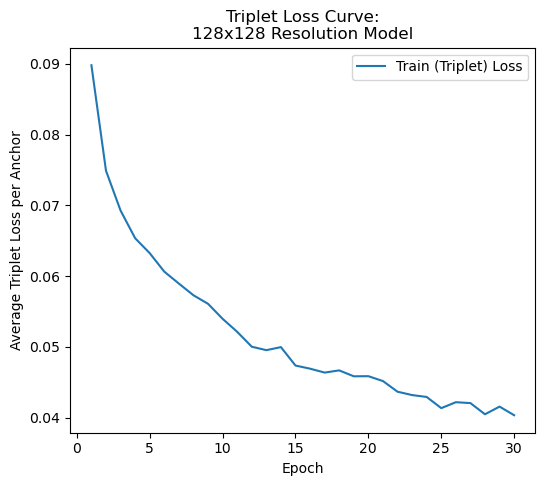

In [26]:
# Get training history
# Import model weights and training results
training_history_path = Path("training_outputs/20260528_145545/training_history.json")

with open(training_history_path, "r") as f:
    training_history = json.load(f)

# Plot triplet loss curve
triplet_loss_values = training_history["triplet_loss"]
epochs = range(1, len(triplet_loss_values) + 1)

plt.figure(figsize=(6, 5))
plt.plot(epochs, triplet_loss_values, label="Train (Triplet) Loss")
plt.xlabel("Epoch")
plt.ylabel("Average Triplet Loss per Anchor")
plt.title(f"Triplet Loss Curve:\n128x128 Resolution Model")
plt.legend()
plt.show()

In [28]:
# CREATE EMBEDDINGS FOR QUERY AND TEST SETS
batch_size=64
image_resolution = 128
base_directory = Path.cwd()  # starting point is the outise the code directory
data_directory = base_directory.parent / 'data' / 'VeRi'

_, query_loader, gallery_loader = create_dataloaders(
        data_directory, image_resolution, batch_size=batch_size
)
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

# Load the trained model weights
model = SimpleReIdModel(embedding_dim=128).to(device)

weights_path = Path("training_outputs/20260528_145545/embedding_model_weights.pth")
model.load_state_dict(torch.load(weights_path, map_location=device))
model.eval()

# Pass query and gallery images through the model to get embeddings
query_embedding_list = []
query_id_list = []

gallery_embedding_list = []
gallery_id_list = []

with torch.no_grad():  
    for batch in query_loader:
        images = batch["image"].to(device)
        ids = batch["vehicle_id"].to(device)
        embeddings = model(images)

        query_embedding_list.append(embeddings.cpu())
        query_id_list.append(ids.cpu())
    
    for batch in gallery_loader:
        images = batch["image"].to(device)
        ids = batch["vehicle_id"].to(device)
        embeddings = model(images)

        gallery_embedding_list.append(embeddings.cpu())
        gallery_id_list.append(ids.cpu())

# Stack all embeddings and IDs into tensors
query_embeddings = torch.cat(query_embedding_list, dim=0)  # (num_queries, embedding_dim)
query_ids = torch.cat(query_id_list, dim=0)  # (num_queries,)
gallery_embeddings = torch.cat(gallery_embedding_list, dim=0)  # (num_gallery, embedding_dim)
gallery_ids = torch.cat(gallery_id_list, dim=0)  # (num_gallery,)

# Calculate cosine similarity between query and gallery embeddings
similarity_matrix = query_embeddings @ gallery_embeddings.T  # (num_queries, num_gallery)

# Sort gallery images for each query based on similarity scores
ranked_similirity = torch.argsort(similarity_matrix, dim=1, descending=True)  # (num_queries, num_gallery)

Using device: mps


**PLOT QUERIES AND RETRIEVALS**

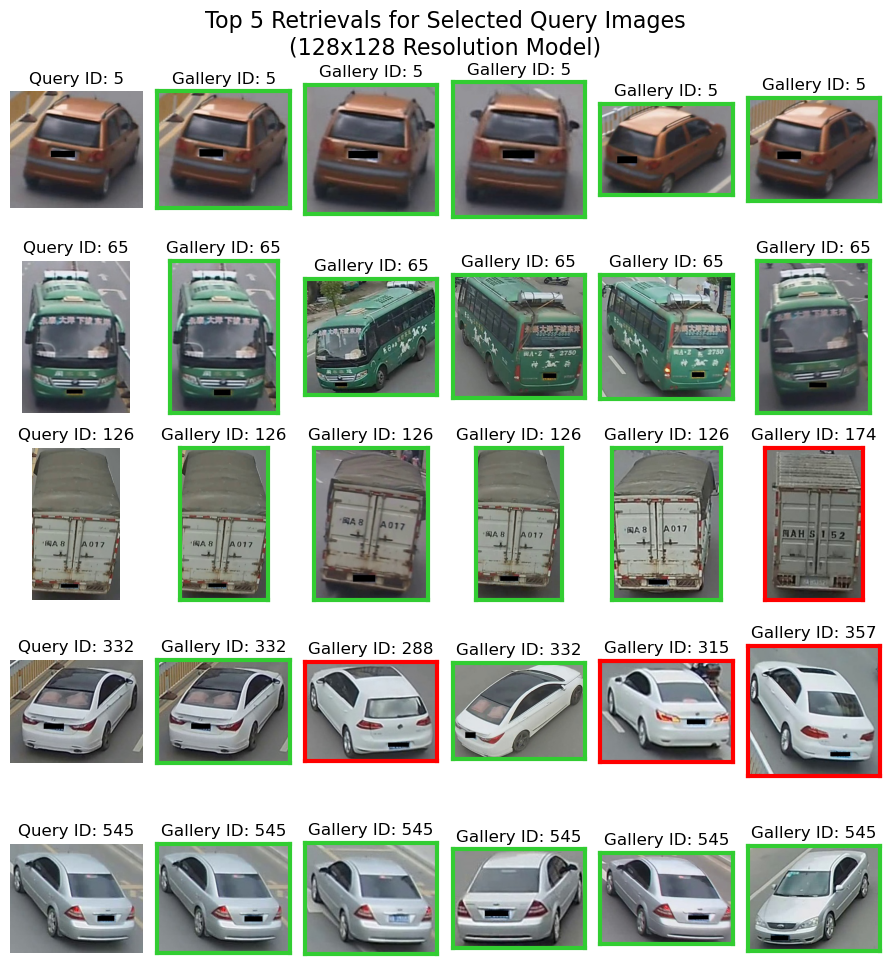

In [38]:
query_indices = [10, 100, 250, 750, 1150]

fig, axes = plt.subplots(len(query_indices), 6, figsize=(9, 10))

for i, query_idx in enumerate(query_indices):
    query_path = query_loader.dataset.image_paths[query_idx]
    query_id = query_ids[query_idx].item()
    top_retrievals_idx = ranked_similirity[query_idx, :5]  # Get top 5 retrievals for the query

    query_img = Image.open(query_path).convert('RGB')
    axes[i, 0].imshow(query_img)
    axes[i, 0].set_title(f"Query ID: {query_id}")
    axes[i, 0].axis('off')

    for rank, gallery_idx in enumerate(top_retrievals_idx):
        gallery_path = gallery_loader.dataset.image_paths[gallery_idx]
        gallery_id = gallery_ids[gallery_idx].item()
        
        gallery_img = Image.open(gallery_path).convert('RGB')
        axes[i, rank + 1].imshow(gallery_img)
        axes[i, rank + 1].set_title(f"Gallery ID: {gallery_id}")
        axes[i, rank + 1].axis('on')
        axes[i, rank + 1].set_xticks([])
        axes[i, rank + 1].set_yticks([])

        ismatch = (query_id == gallery_id)
        border_color = 'limegreen' if ismatch else 'red'

        for spine in axes[i, rank + 1].spines.values():
            spine.set_edgecolor(border_color)
            spine.set_linewidth(3)

plt.suptitle("Top 5 Retrievals for Selected Query Images\n(128x128 Resolution Model)", fontsize=16)
plt.tight_layout()
plt.show()


**TOP K ACCURACY**

In [ ]:
# TOP K ACCURACY
def calculate_top_k_accuracy(query_ids, gallery_ids, ranked_indices, k):
    num_queries = query_ids.shape[0]
    correct_matches = 0

    for i in range(num_queries):
        query_id = query_ids[i].item()
        top_k_gallery_ids = gallery_ids[ranked_indices[i, :k]].cpu().numpy()  # Get top K gallery IDs
        if query_id in top_k_gallery_ids:
            correct_matches += 1

    return correct_matches / num_queries

In [ ]:
top1_accuracy = calculate_top_k_accuracy(
    query_ids, gallery_ids, ranked_similirity, k=1
)

top5_accuracy = calculate_top_k_accuracy(
    query_ids, gallery_ids, ranked_similirity, k=5
)

print(f"Top-1 Accuracy: {top1_accuracy:.4f}")
print(f"Top-5 Accuracy: {top5_accuracy:.4f}")

**MEAN AVERAGE PRECISION**

In [ ]:
# FUNCTION TO CALCULATE MEAN AVERAGE PRECISION (mAP)
def mean_average_precision(ranked_indices, query_ids, gallery_ids):
    ranked_indices = ranked_indices.cpu()
    query_ids = query_ids.cpu()
    gallery_ids = gallery_ids.cpu()
    
    num_queries = query_ids.shape[0]
    average_precisions = []

    for i in range(num_queries):
        query_id = query_ids[i].item()
        ranked_gallery_ids = gallery_ids[ranked_indices[i]]

        # Calculate precision at each rank position
        correct_matches = (ranked_gallery_ids == query_id).int()
        cumulative_correct = torch.cumsum(correct_matches, dim=0)

        # Precision at each rank
        running_precision = cumulative_correct / torch.arange(1, len(ranked_gallery_ids) + 1)

        # Only take indices where there is a correct match
        relevant_indices = torch.where(correct_matches == 1)[0]
        if len(relevant_indices) > 0:
            average_precision = running_precision[relevant_indices].mean().item()
        else:
            average_precision = 0.0

        average_precisions.append(average_precision)

    return torch.mean(torch.tensor(average_precisions)).item()

In [ ]:
map_score = mean_average_precision(ranked_similirity, query_ids, gallery_ids)
print(f"Mean Average Precision (mAP): {map_score:.4f}")

---
End of notebook.